### Load Enriched Dataset

In [50]:
import pandas as pd

df = pd.read_csv("data/elite_data/enriched.csv")
df = df.sample(100000,random_state=42)

print(df.shape)
df.head()

(100000, 30)


,timestamp,transaction_id,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,...,dayofweek,is_weekend,date,tx_count_24h,amt_sum_24h,unique_receivers_day,device_accounts_count,ip_accounts_count,device_fraud_rate,ip_fraud_rate
781974,2023-09-30 15:04:14.072158+00:00,T439591,ACC360128,ACC113994,6.24,payment,utilities,singapore,web,False,...,5,1,2023-09-30,1.0,6.24,1,1,1,0.0,0.0
937737,2023-11-23 18:19:22.898578+00:00,T646795,ACC737393,ACC290806,339.03,payment,grocery,singapore,mobile,False,...,3,0,2023-11-23,1.0,339.03,1,1,1,0.0,0.0
907828,2023-11-13 07:58:14.048854+00:00,T520341,ACC628062,ACC747041,211.11,withdrawal,grocery,toronto,atm,False,...,0,0,2023-11-13,1.0,211.11,1,1,1,0.0,0.0
784628,2023-10-01 12:28:21.664196+00:00,T294741,ACC793392,ACC242517,156.34,withdrawal,grocery,berlin,pos,False,...,6,1,2023-10-01,1.0,156.34,1,1,1,0.0,0.0
662460,2023-08-19 23:39:55.233225+00:00,T224768,ACC696680,ACC278703,77.48,payment,other,sydney,atm,False,...,5,1,2023-08-19,1.0,77.48,1,1,1,0.0,0.0


### Select Columns Needed For Graph

In [51]:
graph_df = df[[
    "sender_account",
    "receiver_account",
    "device_hash",
    "ip_address",
    "location",
    "merchant_category",
    "amount_wins",
    "velocity_score",
    "spending_deviation_score",
    "geo_anomaly_score",
    "tx_count_24h",
    "amt_sum_24h",
    "device_fraud_rate",
    "ip_fraud_rate",
    "is_fraud"
]]

### Build Graph (NetworkX Prototype)

In [52]:
import networkx as nx

sample_df = graph_df.sample(100000, random_state=42)

G = nx.MultiDiGraph()

for _, row in sample_df.iterrows():
    
    sender = "acc_" + str(row["sender_account"])
    receiver = "acc_" + str(row["receiver_account"])
    device = "dev_" + str(row["device_hash"])
    ip = "ip_" + str(row["ip_address"])
    location = "loc_" + str(row["location"])
    merchant = "mer_" + str(row["merchant_category"])
    
    # add nodes
    G.add_node(sender, type="account")
    G.add_node(receiver, type="account")
    G.add_node(device, type="device")
    G.add_node(ip, type="ip")
    G.add_node(location, type="location")
    G.add_node(merchant, type="merchant")
    
    # transaction edge (Account → Account)
    G.add_edge(
        sender,
        receiver,
        type="transaction",
        fraud=row["is_fraud"],
        amount=row["amount_wins"]
    )
    
    # account → device
    G.add_edge(sender, device, type="uses_device")
    
    # account → ip
    G.add_edge(sender, ip, type="uses_ip")
    
    # account → location
    G.add_edge(sender, location, type="located_at")
    
    # account → merchant
    G.add_edge(sender, merchant, type="purchases")

### Inspect Graph

In [53]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 379078
Edges: 500000


### Visualize Small Subgraph

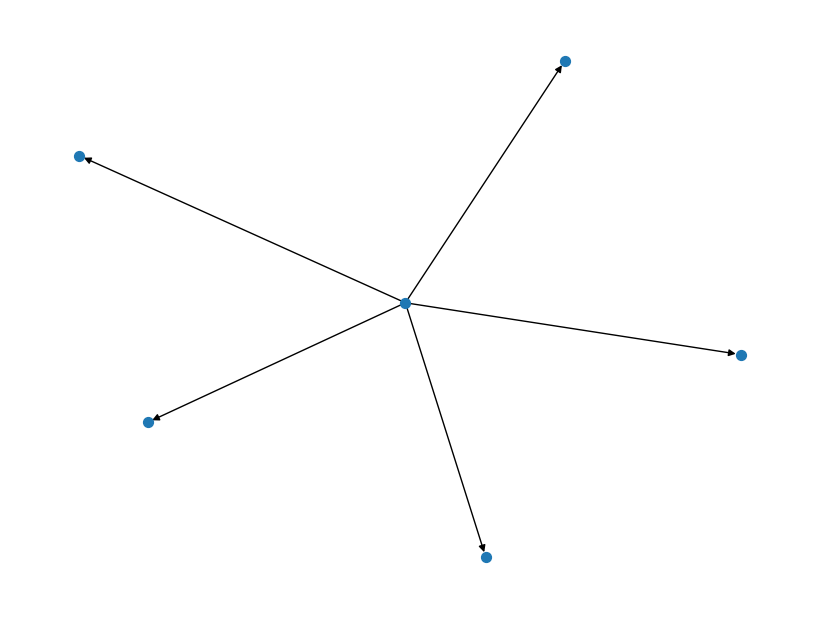

In [54]:
import matplotlib.pyplot as plt

sub = nx.ego_graph(G, list(G.nodes())[0], radius=2)

plt.figure(figsize=(8,6))
nx.draw(sub, node_size=50)
plt.show()

### Saving Graph

In [55]:
import pickle

with open("data/transaction_graph.pkl", "wb") as f:
    pickle.dump(G, f)

In [56]:
location = "loc_" + row["location"]
merchant = "mer_" + row["merchant_category"]

G.add_node(location, type="location")
G.add_node(merchant, type="merchant")

G.add_edge(sender, location, type="located_at")
G.add_edge(sender, merchant, type="purchases")

1

In [57]:
from collections import Counter

node_types = Counter(nx.get_node_attributes(G, "type").values())
print(node_types)

Counter({'account': 179590, 'ip': 99999, 'device': 99473, 'location': 8, 'merchant': 8})


In [58]:
Counter([data["type"] for _,_,data in G.edges(data=True)])

Counter({'located_at': 100001,
         'purchases': 100001,
         'transaction': 100000,
         'uses_device': 100000,
         'uses_ip': 100000})

In [59]:
print("Unique accounts:", len(set(df.sender_account) | set(df.receiver_account)))
print("Unique devices:", df.device_hash.nunique())
print("Unique IPs:", df.ip_address.nunique())

Unique accounts: 179590
Unique devices: 99473
Unique IPs: 99999


In [60]:
print(df.memory_usage(deep=True).sum()/1e9, "GB")

0.08777675 GB


In [61]:
df[[
    "velocity_score",
    "spending_deviation_score",
    "geo_anomaly_score",
    "tx_count_24h",
    "amt_sum_24h"
]].head()

,velocity_score,spending_deviation_score,geo_anomaly_score,tx_count_24h,amt_sum_24h
781974,2,-0.68,0.44,1.0,6.24
937737,1,0.41,0.72,1.0,339.03
907828,13,1.29,0.38,1.0,211.11
784628,20,-1.82,0.62,1.0,156.34
662460,19,-0.45,0.81,1.0,77.48
